In [21]:
!pip install kaggle

In [22]:
kaggle = '/content/kaggle.json'

In [23]:
!mkdir -p ~/.kaggle
!cp {kaggle} ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [24]:
!kaggle datasets download -d olafkrastovski/handwritten-digits-0-9

Dataset URL: https://www.kaggle.com/datasets/olafkrastovski/handwritten-digits-0-9
License(s): CC0-1.0
handwritten-digits-0-9.zip: Skipping, found more recently modified local copy (use --force to force download)


In [25]:
from zipfile import ZipFile
import os
file_name = 'handwritten-digits-0-9.zip'

extract_folder = "dataset"
os.makedirs(extract_folder, exist_ok= True)

with ZipFile(file_name, 'r') as zip:
  zip.extractall(extract_folder)
  print('Done')

Done


In [26]:
data_0 = os.listdir('/content/dataset/0')
data_1 = os.listdir('/content/dataset/1')
data_2 = os.listdir('/content/dataset/2')
data_3 = os.listdir('/content/dataset/3')
data_4 = os.listdir('/content/dataset/4')
data_5 = os.listdir('/content/dataset/5')
data_6 = os.listdir('/content/dataset/6')
data_7 = os.listdir('/content/dataset/7')
data_8 = os.listdir('/content/dataset/8')
data_9 = os.listdir('/content/dataset/9')

In [27]:
len(data_0)

2236

In [28]:
import cv2
import numpy as np
from sklearn.model_selection import train_test_split

X = []
y = []

data_lists = [data_0, data_1, data_2, data_3, data_4, data_5, data_6, data_7, data_8, data_9]

for digit, data_list in enumerate(data_lists):
    for image_name in data_list:

        image_path = os.path.join(extract_folder, str(digit), image_name)
        img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
        img = cv2.resize(img, (28, 28))
        img = img.flatten()

        X.append(img)
        y.append(digit)


X = np.array(X)
y = np.array(y)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data processing complete.")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

Data processing complete.
X_train shape: (17244, 784)
X_test shape: (4311, 784)
y_train shape: (17244,)
y_test shape: (4311,)


In [29]:
X_train = X_train / 255.0
X_test = X_test / 255.0

print("Data normalization complete.")
print(f"X_train min: {X_train.min()}, max: {X_train.max()}")
print(f"X_test min: {X_test.min()}, max: {X_test.max()}")

Data normalization complete.
X_train min: 0.0, max: 1.0
X_test min: 0.0, max: 1.0


In [55]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

# 2. Inisialisasi model Sequential
model = Sequential()

# 3. Tambahkan lapisan input Dense
# X_train.shape[1] will be 784 (28*28 pixels)
model.add(Dense(128, activation='relu', input_shape=(X_train.shape[1],)))

# 4. Tambahkan lapisan tersembunyi Dense tambahan
model.add(Dense(64, activation='relu'))

# 5. Tambahkan lapisan output Dense
# 10 units for 10 digits (0-9), softmax for multi-class classification
model.add(Dense(10, activation='sigmoid'))

# 6. Kompilasi model
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Tampilkan ringkasan model
model.summary()

print("MLP model defined and compiled successfully.")

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_18 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

MLP model defined and compiled successfully.


In [56]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop= EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [57]:
history = model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=16,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

print("Model training complete.")

Epoch 1/100
863/863 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.1156 - loss: 2.3276 - val_accuracy: 0.1540 - val_loss: 2.3095
Epoch 2/100
863/863 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.2037 - loss: 2.1365 - val_accuracy: 0.3053 - val_loss: 1.9581
Epoch 3/100
863/863 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.2863 - loss: 1.9821 - val_accuracy: 0.3166 - val_loss: 1.8979
Epoch 4/100
863/863 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3302 - loss: 1.8724 - val_accuracy: 0.3671 - val_loss: 1.8017
Epoch 5/100
863/863 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3681 - loss: 1.8123 - val_accuracy: 0.3949 - val_loss: 1.7619
Epoch 6/100
863/863 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.3898 - loss: 1.7728 - val_accuracy: 0.3865 - val_loss: 1.7744
Epoch 7/100
863/863 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.4110 - loss: 1.7270 - val_accuracy: 0.4198 - val_loss: 1.6980
Epoch 8/100
863/863 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.4316 - loss: 1.6695 - val_accu

In [58]:
loss, accuracy = model.evaluate(X_test, y_test)

print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5915 - loss: 1.2337
Test Loss: 1.2120
Test Accuracy: 0.6003


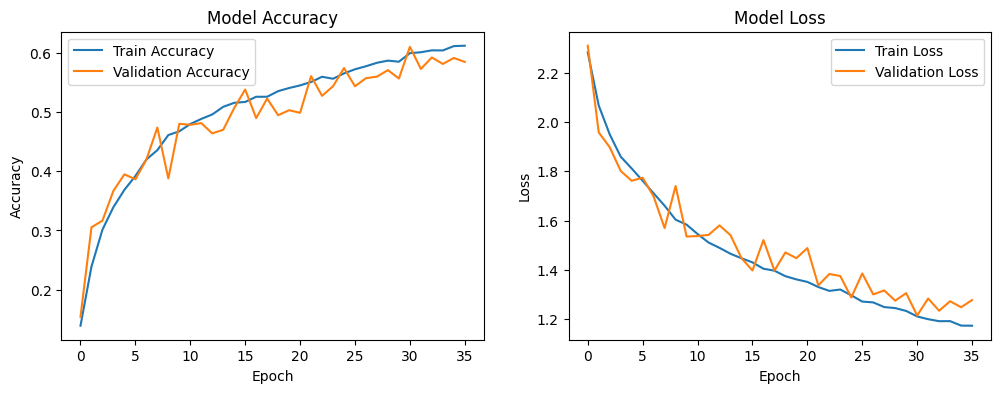

In [59]:
plt.figure(figsize=(12,4))

#accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

#loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


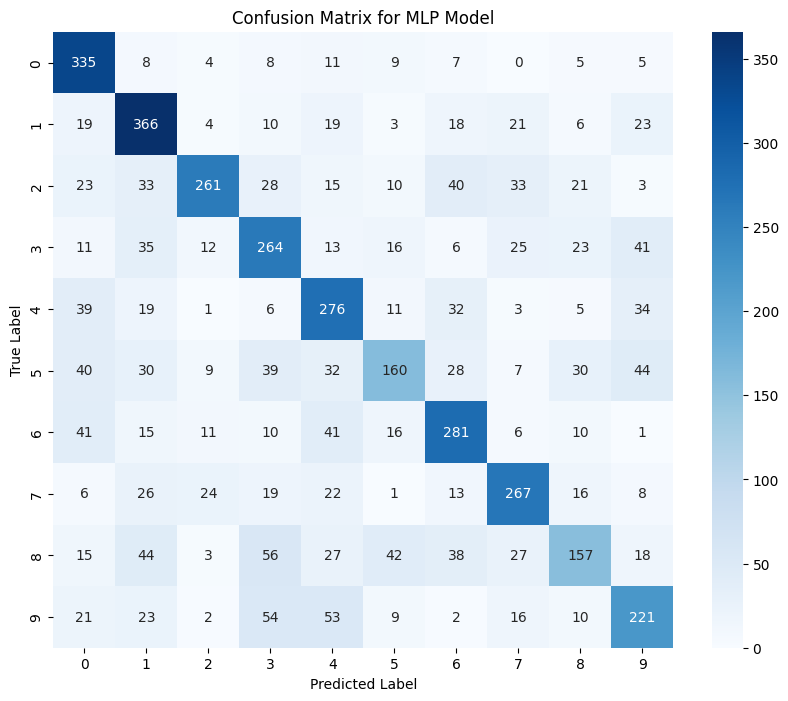

In [60]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Lakukan prediksi pada data pengujian
y_pred_prob = model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)

# Hitung confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Visualisasikan confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for MLP Model')
plt.show()